<a href="https://colab.research.google.com/github/chaitanysaraswat/Advanced-Analytics-Using-Statistics/blob/main/lecture19_20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
import sklearn
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
from numpy import random
from collections import Counter
from numpy.linalg import inv
from numpy.linalg import eig
import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns
import pylab
from pylab import legend
from pylab import plot, show, title, xlabel, ylabel
import scipy
from scipy import stats
from scipy.stats import binom,poisson,norm,t,expon,f
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor

In [2]:
df = pd.read_excel('/content/drive/MyDrive/CDAC_stats/CDAC_DataBook.xlsx', sheet_name = 'diabetes')
df = df[['Glucose','BloodPressure','Age','DietType','Outcome']]

diet_dummy = pd.get_dummies(df.DietType, drop_first=True, prefix='Diet').astype(int)
df = df.drop('DietType', axis=1)
df = pd.concat([df,diet_dummy], axis=1)

x= df.drop('Outcome', axis=1)  # column of predictors
y= df.Outcome   # column of response

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=20)

dtc = DecisionTreeClassifier()
dtc.fit(x_train,y_train)

y_pred=dtc.predict(x_test)
from sklearn.metrics import confusion_matrix,classification_report

print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

print(dtc.score(x_train, y_train))   # training data accuracy
print(dtc.score(x_test, y_test))    # test data accuracy

# hyperparameter tuning

param={
    'criterion':['gini','entropy', 'log_loss'],
    'splitter':['best','random'],
    'max_depth':[1,2,3,4,5,6,7],
    'max_features':['auto','sqrt','log2'],
    'min_samples_split' : [2,3,4,5],
    'min_samples_leaf' : [2,3,4,5]
}

from sklearn.model_selection import GridSearchCV
grid=GridSearchCV(dtc,param_grid=param,cv=5,scoring='accuracy')
grid.fit(x_train,y_train)
grid.best_params_

dtc = DecisionTreeClassifier(criterion= 'gini',
 max_depth= 5,
 max_features= 'sqrt',
 min_samples_leaf= 5,
 min_samples_split= 2,
 splitter= 'best')

dtc.fit(x_train,y_train)
print(dtc.score(x_train, y_train))   # training data accuracy
print(dtc.score(x_test, y_test))    # test data accuracy

y_pred = dtc.predict(x_test)
print(confusion_matrix(y_test,y_pred))

[[85 16]
 [16 37]]
              precision    recall  f1-score   support

           0       0.84      0.84      0.84       101
           1       0.70      0.70      0.70        53

    accuracy                           0.79       154
   macro avg       0.77      0.77      0.77       154
weighted avg       0.79      0.79      0.79       154

1.0
0.7922077922077922
0.8550488599348535
0.8376623376623377
[[88 13]
 [12 41]]


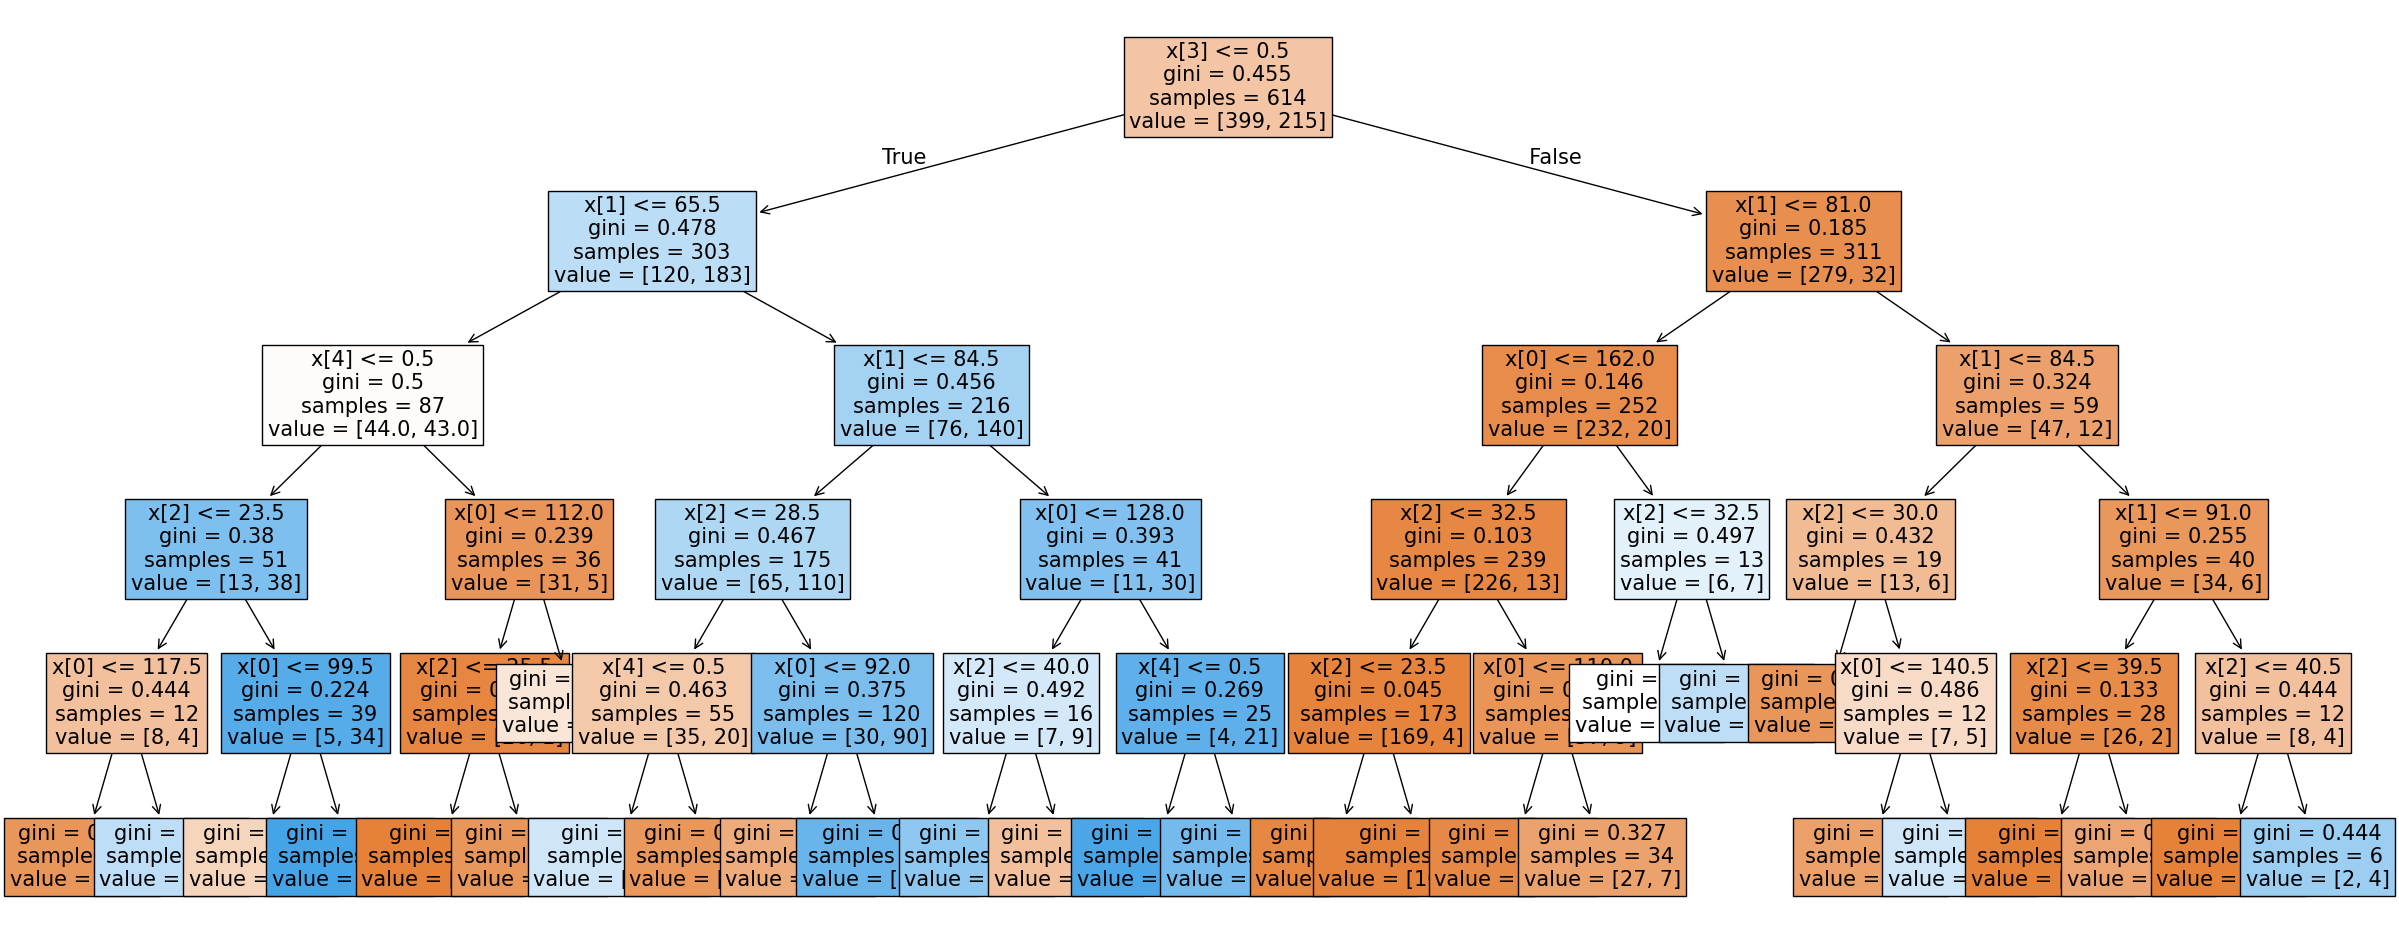

In [3]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(30,12))
tree.plot_tree(
    dtc,
    filled=True,
    fontsize=15
)
plt.show()

In [4]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(n_estimators=50,max_depth=4)
rfc.fit(x_train,y_train)
print(rfc.score(x_train, y_train))   # training data accuracy
print(rfc.score(x_test, y_test))    # test data accuracy

0.8827361563517915
0.8766233766233766


RANDOM FOREST(N* DECISION TREE) :

- would be group of certain x no of decision tree
- the decision in random forest taken by majority or mode of response in categorical
 and in continuous response average will be taken
- random forest will have all the hyperparameter of decision tree plus one more n_estimators
---
DECISION TREE IS LESS PRONE TO OUTLIERS THAN LINEAR REGRESSION becoz best fit line will be moved to the outlier data

FOR FEATURE SELECTION WE WILL USE:

- LASSO

- MULTICOLLINARITY(VIF)

- COEFFICIENT OF VARIATION

- P VALUE USING INFERENTIAL TOOLS

- IF VARIATION IS LESS IN DATA

- EMPIRICAL TOOL: INFO GAIN

FIRST DECISION TREE IN THE SERIES OF BOOSTING MODEL IS CALLED WEAK LEARNER.

LAST DECISION TREE IS CALLED STRONG BOOSTING MODEL


---
| P1 (PREDICTION) | A (ACTUAL) | E (ERROR) | 0.1 * E (LEARNING RATE * ERROR) | P2 (NEW PRED) |
| :---: | :---: | :---: | :---: | :---: |
| 8 | 9.3 | 1.3 | 0.13 | 8.13 |
---

IF WE MAKE BIG ADJUSTMENT TO PREDICTION WE WILL LOST POINT OF MINIMA WHICH HAS LESS DIFF B/W PRED AND ACTUAL


P=P+0.1NLV

NLV=AVG RESIDUAL/HESSIAN(VARIANCE)

WHEN AND WHY NLV BIGGER:

The NLV is a ratio of how far we are from the point of minima to the variance

- if residual is high and variance is low than the value of NLV is high
 so bigger change can be made in original logic

- if residual is low and variance is high than the value of NLV is low
 so lesser change can be made in original logic


- new weight are calculated in such a way by ensuring that the rows where the error is high should get high weights

adboost continuous  gini impurity-->split-->left and right-->residual value-->alpha -->total cumulative error-->update weight-->calculative alpha and individual rsidual-->residualincreases weight increase

# Gradient Boosting (Regression)

### Step 1: Build the Base Model

* Calculate the average of the target variable.
* This average value becomes the initial prediction for all rows.

$$
\hat{y}_0 = \frac{\sum y_i}{N}
$$

---

### Step 2: Calculate Residuals

* Compute the residual (error) for each row.

$$
Residual = Actual - Prediction
$$

* Residuals represent the information that the current model has failed to learn.

---

### Step 3: Train the First Decision Tree

* Fit a decision tree on the residuals instead of the original target variable.
* The tree learns the patterns present in the errors.

---

### Step 4: Make Residual Predictions

* Use the decision tree to predict the residuals for each observation.
* These predicted residuals indicate how much the current prediction should be corrected.

---

### Step 5: Update Predictions

* Add the predicted residuals to the previous predictions.

$$
New\ Prediction =
Old\ Prediction + Learning\ Rate \times Predicted\ Residual
$$

* The learning rate controls how much correction is applied at each step.

---

### Step 6: Calculate New Residuals

* Compute the new residuals using the updated predictions.

$$
Residual = Actual - New\ Prediction
$$

* The errors should now be smaller than before.

---

### Step 7: Build the Next Tree

* Train another decision tree on the new residuals.
* This tree focuses on the mistakes that the previous trees could not correct.

---

### Step 8: Repeat the Process

* Continue building trees sequentially.
* Each new tree learns from the residuals of the previous model.

---

### Final Prediction

$$
Final\ Prediction =
Base\ Prediction
+
\eta T_1
+
\eta T_2
+
\eta T_3
+\cdots+
\eta T_n
$$

Where:

* (\eta) = Learning Rate
* (T_1, T_2, ..., T_n) = Predictions from individual trees

---

## Key Idea

* AdaBoost increases the weight of incorrectly predicted observations.
* Gradient Boosting fits a new tree on the residuals (errors) of the previous model.
* Each tree tries to reduce the remaining error left by the earlier trees.
* Trees are added sequentially until the residuals become very small.


# AdaBoost (Continuous Data)

### Step 1

* Equal weights are assigned to all rows initially.
* Base predictions are made using the average value of the target variable.

### Step 2

* Calculate the residual (error) for each row.
* Update the weights based on the residuals.
* Rows with higher residuals receive higher weights, while rows with lower residuals receive lower weights.

### Step 3

* The updated weights determine how frequently each row will be selected for the next decision tree.
* Rows with higher weights have a greater chance of appearing multiple times in the next training sample.

### Step 4

* During the construction of the next decision tree, rows with larger residuals (higher weights) appear more often than rows with smaller residuals (lower weights).
* As a result, the model focuses more on observations with larger prediction errors.

### Note

* For continuous data, regions containing larger errors tend to receive more attention from subsequent trees.
* This often results in larger bins/partitions being created to better capture and reduce those errors.


# XGBOOST:
Loss Function:
$$
L = \frac{1}{2N}\sum_{i=1}^{N}(y_i-\hat{y}_i)^2
$$

THE FIRST DERIVATIVE OF LOSS FUCNTION IS CONSIDERED AS DEVIATION FROM THE TARGET OR RESIDUAL AND

 2ND DEIVATIVE WILL BE CONSTANT TERM

$$
Gain =
\frac{1}{2}
\left(
\frac{G_L^2}{H_L+\lambda}
+
\frac{G_R^2}{H_R+\lambda}
-
\frac{(G_L+G_R)^2}{H_L+H_R+\lambda}
\right)
-\gamma
$$

Similarity Score:
$$
w_j
=
-\frac{\sum g_i}{\sum h_i+\lambda}
$$

wj formula sigma z gi(sum of all gradient) that first derivative in numerator and in denominator is (second derivative)


# XGBoost Tree Splitting Process

### STEP 1: Calculate Base Response
- FIRST AVG = (SUM RESPONSE / COUNT OF RESPONSE)
- THAT WILL BE BASE RESPONSE

---

### STEP 2: Calculate Gradient and Hessian
- Gradient = Residual = (Pred1 - Response Column)
- Hessian will be 1 as a constant column

---

### STEP 3: Calculate Left and Right Node Statistics

#### Right Node
- Right Node Gradient = Sum of Right Node Gradients
- Right Node Hessian = Sum of Right Node Hessians

#### Left Node
- Left Node Gradient = Sum of Left Node Gradients
- Left Node Hessian = Sum of Left Node Hessians

---

### STEP 4: Calculate Leaf Weights (Wj)

#### Left Node
- Wj = Left Node Gradient / (Left Node Hessian + 1)

#### Right Node
- Wj = Right Node Gradient / (Right Node Hessian + 1)

---

### STEP 5: Calculate Gain

Assume Gamma = 0

Gain Formula:

Gain = 0.5 × (
    (Sum Left Gradient² / (Hessian Left + Lambda(1)))
    +
    (Sum Right Gradient² / (Hessian Right + Lambda(1)))
)

- If Gain calculated is negative, then split is not performed.

---

# Gamma (γ)

- Very high value of Gamma ---> Gain low or negative ---> Splitting will be negative or not possible ---> Overfitting avoided

- Gamma is too high ---> Then it may lead to Underfitting

---

# Lambda (λ)

- High value of Lambda will increase Hessian / Variance

- It will stop splitting


## Lasso Regularization Leaf Weight Formula

$$
w =
-\frac{\operatorname{sign}(G)\,\max(|G|-\alpha,0)}
{H+\lambda}
$$

Where:

G = Sum of Gradients (First Derivatives)

H = Sum of Hessians (Second Derivatives)

α = L1 Regularization Parameter

λ = L2 Regularization Parameter

sign(G) returns:

+1 if G>0

−1 if G<0

0 if G=0

- Alpha reduces the magnitude of the gradient which appears in numerator for the leaf weight calculation

- this reduction in leaf weight will decrease the change made in the earlier prediction


eta * wj

will help to make changes

PROBABILITY:-->bayestheirem-->naive baeyes theorem

In [5]:
df=pd.read_excel('/content/drive/MyDrive/CDAC_stats/CDAC_DataBook.xlsx',sheet_name='diabetes')
df.head()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,DietType
0,148,72,35,0,33.6,0.63,50,1,1
1,85,66,29,0,26.6,0.35,31,0,2
2,183,64,0,0,23.3,0.67,32,1,1
3,89,66,23,94,28.1,0.17,21,0,1
4,137,40,35,168,43.1,2.29,33,1,1


In [6]:
df = df[['Glucose','BloodPressure','Age','DietType','Outcome']]
diet_dummy = pd.get_dummies(df.DietType, drop_first=True, prefix='Diet').astype(int)
df.drop('DietType', axis=1, inplace=True)
df = pd.concat([df,diet_dummy], axis=1)
x_train, x_test, y_train, y_test = train_test_split(df.drop('Outcome',axis=1), df.Outcome, random_state=20, test_size=0.2)

from sklearn.tree import DecisionTreeClassifier
dtc=DecisionTreeClassifier(max_depth=4)
dtc.fit(x_train,y_train)
print(dtc.score(x_train, y_train))   # training data accuracy
print(dtc.score(x_test, y_test))    # test data accuracy

0.8908794788273615
0.8831168831168831


In [7]:
from sklearn.ensemble import GradientBoostingClassifier
gbc=GradientBoostingClassifier()


In [8]:
my_params = {'learning_rate':[0.001,0.005,0.01,0.05,0.1,0.15,0.2],
           'n_estimators':[30,50,70,100,150],
           'max_depth':[2,3,4,5]}

from sklearn.model_selection import GridSearchCV
grid=GridSearchCV(gbc,param_grid=my_params,cv=5,scoring='accuracy')
grid.fit(x_train,y_train)
grid.best_params_



{'learning_rate': 0.2, 'max_depth': 2, 'n_estimators': 70}

In [9]:
gbc = GradientBoostingClassifier(learning_rate=0.1, max_depth=4, n_estimators=50)
gbc.fit(x_train,y_train)
print(gbc.score(x_train, y_train))   # training data accuracy
print(gbc.score(x_test, y_test))    # test data accuracy

0.9495114006514658
0.8831168831168831


In [10]:
from sklearn.ensemble import AdaBoostClassifier
abc = AdaBoostClassifier()

my_params = {'learning_rate':[0.001,0.005,0.01,0.05,0.1,0.15,0.2],
           'n_estimators':[30,50,70,100,150],
           }

from sklearn.model_selection import GridSearchCV
grid=GridSearchCV(abc,param_grid=my_params,cv=5,scoring='accuracy')
grid.fit(x_train,y_train)
grid.best_params_



{'learning_rate': 0.2, 'n_estimators': 100}

In [11]:
abc = AdaBoostClassifier(learning_rate=0.2, n_estimators= 100)
abc.fit(x_train,y_train)
print(abc.score(x_train, y_train))   # training data accuracy
print(abc.score(x_test, y_test))    # test data accuracy

0.8745928338762216
0.8831168831168831


In [12]:
import xgboost
from xgboost import XGBClassifier
xgbc = XGBClassifier()

my_params = {'learning_rate':[0.001,0.005,0.01,0.05,0.1,0.15,0.2],
           'reg_lambda':[0.1,0.5,1,2,3],
           'reg_alpha':[0.005,0.05,0.1,0.2,0.5,1,1.5,2],
           'gamma':[0.1,0.5,1,2,3,5]
           }
from sklearn.model_selection import GridSearchCV
grid=GridSearchCV(xgbc,param_grid=my_params,cv=5,scoring='accuracy')
grid.fit(x_train,y_train)
grid.best_params_


{'gamma': 2, 'learning_rate': 0.05, 'reg_alpha': 0.5, 'reg_lambda': 0.1}

In [13]:
xgbc = XGBClassifier()
xgbc.fit(x_train,y_train)
print(xgbc.score(x_train, y_train))   # training data accuracy
print(xgbc.score(x_test, y_test))    # test data accuracy

0.996742671009772
0.8506493506493507


Mutually exclusive events p(A INTERSEXTION B) =0
A AND B DOESNT HAPPEN TOGETHER THAT IS MUTUALLY EXCLUSIVE

INDEPENDENT EVENT P(A|B) =P(A)
FOR MUT